# Даследванне лінейнай рэгрэсіі

Датасэт: https://www.kaggle.com/datasets/vishakhdapat/price-of-used-toyota-corolla-cars

Галоўная задача — прадказваць кошт паводле параметраў машыны.

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [24]:
df = pd.read_csv("ToyotaCorolla.csv", low_memory=False)

In [25]:
df.shape

(1436, 39)

Датасэт змяшчае 1436 радкоў назіранняў па 39 параметрах.

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Id                 1436 non-null   int64
 1   Model              1436 non-null   str  
 2   Price              1436 non-null   int64
 3   Age_08_04          1436 non-null   int64
 4   Mfg_Month          1436 non-null   int64
 5   Mfg_Year           1436 non-null   int64
 6   KM                 1436 non-null   int64
 7   Fuel_Type          1436 non-null   str  
 8   HP                 1436 non-null   int64
 9   Met_Color          1436 non-null   int64
 10  Color              1436 non-null   str  
 11  Automatic          1436 non-null   int64
 12  CC                 1436 non-null   int64
 13  Doors              1436 non-null   int64
 14  Cylinders          1436 non-null   int64
 15  Gears              1436 non-null   int64
 16  Quarterly_Tax      1436 non-null   int64
 17  Weight             1436 n

(пропускаў няма)

In [27]:
numeric_cols = [
    "Price",
    "Age_08_04",
    "KM",
    "HP",
    "CC",
    "Weight",
    "Quarterly_Tax",
    "Doors",
    "Gears",
    "Cylinders"
]

df[numeric_cols].describe()

,Price,Age_08_04,KM,HP,CC,Weight,Quarterly_Tax,Doors,Gears,Cylinders
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.00000,1436.000000,1436.000000,1436.000000,1436.0
mean,10730.824513,55.947075,68533.259749,101.502089,1576.85585,1072.45961,87.122563,4.033426,5.026462,4.0
std,3626.964585,18.599988,37506.448872,14.981080,424.38677,52.64112,41.128611,0.952677,0.188510,0.0
min,4350.000000,1.000000,1.000000,69.000000,1300.00000,1000.00000,19.000000,2.000000,3.000000,4.0
25%,8450.000000,44.000000,43000.000000,90.000000,1400.00000,1040.00000,69.000000,3.000000,5.000000,4.0
50%,9900.000000,61.000000,63389.500000,110.000000,1600.00000,1070.00000,85.000000,4.000000,5.000000,4.0
75%,11950.000000,70.000000,87020.750000,110.000000,1600.00000,1085.00000,85.000000,5.000000,5.000000,4.0
max,32500.000000,80.000000,243000.000000,192.000000,16000.00000,1615.00000,283.000000,5.000000,6.000000,4.0


In [28]:
df["Model"].value_counts()

Model
TOYOTA Corolla 1.6 16V HATCHB LINEA TERRA 2/3-Doors    109
TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-Doors     84
TOYOTA Corolla 1.6 16V LIFTB LINEA LUNA 4/5-Doors       80
TOYOTA Corolla 1.6 16V LIFTB LINEA TERRA 4/5-Doors      71
TOYOTA Corolla 1.4 16V VVT I HATCHB TERRA 2/3-Doors     54
                                                      ... 
TOYOTA Corolla 1.6 SDN LINEA TERRA AUT 4/5-Doors         1
TOYOTA Corolla 1.3 HB LINEA TERRA AUT 2/3-Doors          1
TOYOTA Corolla 1.3 Linea Terra sedan 4/5-Doors           1
TOYOTA Corolla 1.6 Lin.Terra Aut. 2/3-Doors              1
TOYOTA Corolla 1.3 Linea Terra 4/5-Doors                 1
Name: count, Length: 319, dtype: int64

Існуе 319 варыянтаў мадэляў. Параметр непаказальны, таму ня ўключаны ў numeric_cols. 

In [29]:
df["Fuel_Type"].value_counts()

Fuel_Type
Petrol    1264
Diesel     155
CNG         17
Name: count, dtype: int64

In [30]:
df["Color"].value_counts()

Color
Grey      301
Blue      283
Red       278
Green     220
Black     191
Silver    122
White      31
Violet      4
Yellow      3
Beige       3
Name: count, dtype: int64

## Гістаграмы размеркавання

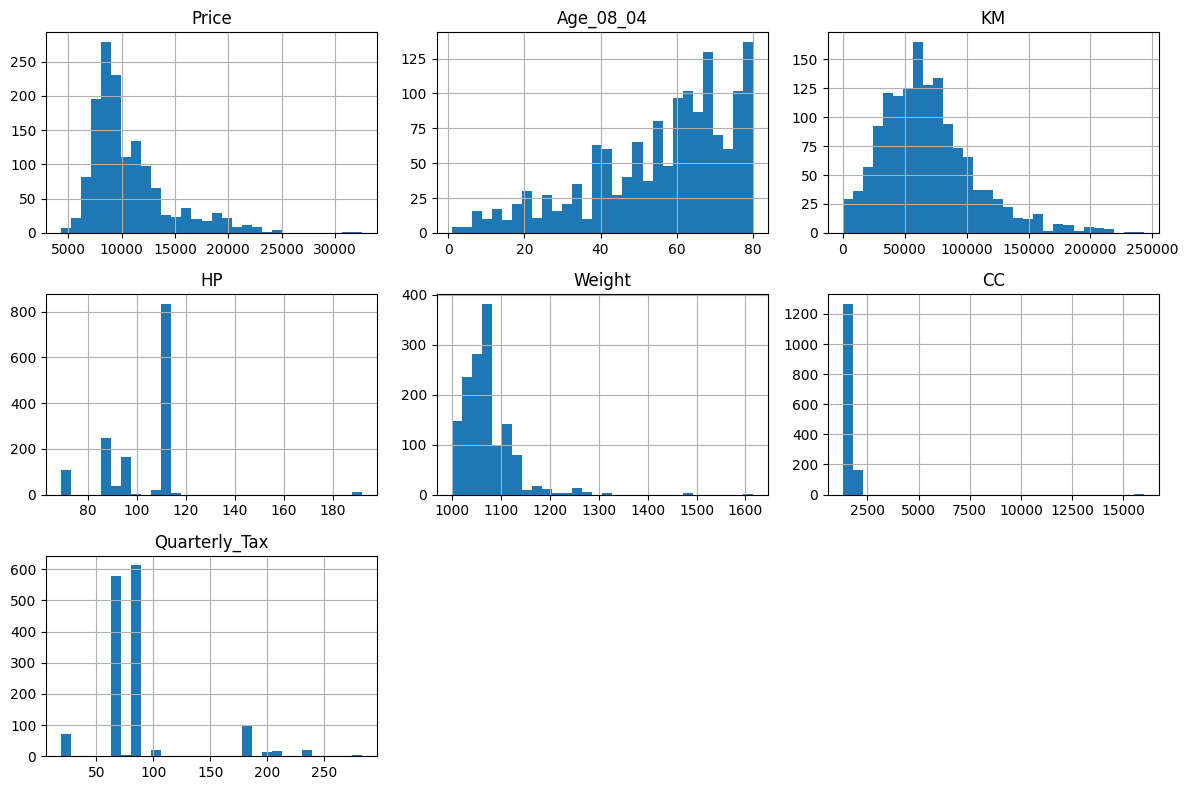

In [31]:
hist_cols = [
    "Price",
    "Age_08_04",
    "KM",
    "HP",
    "Weight",
    "CC",
    "Quarterly_Tax"
]

df[hist_cols].hist(
    figsize=(12,8),
    bins=30
)

plt.tight_layout()
plt.show()

## Пошук выбрасаў

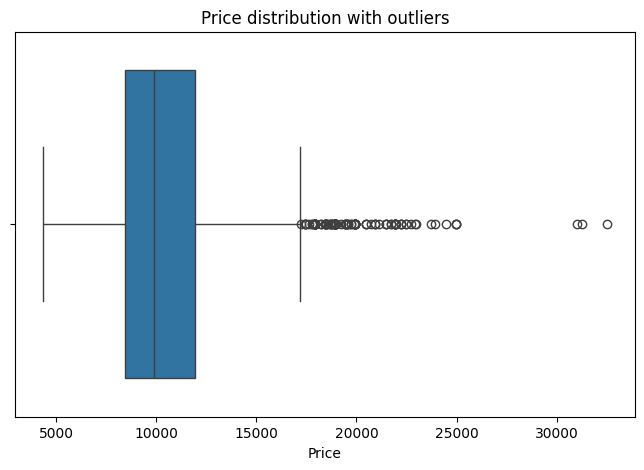

In [32]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Price"])
plt.title("Price distribution with outliers")
plt.show()

## Матрыца карэляцый

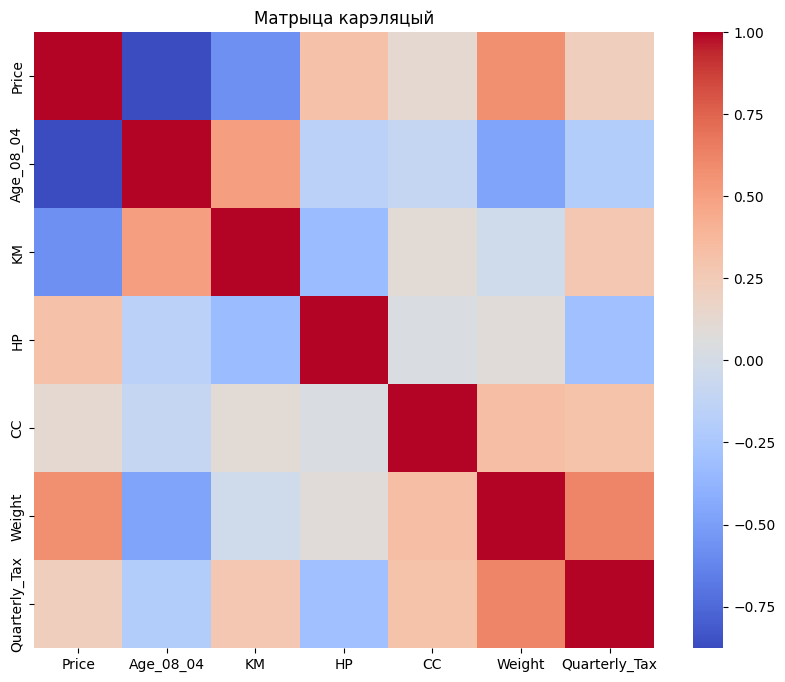

Price                1.000000
Mfg_Year             0.885159
Boardcomputer        0.601292
Automatic_airco      0.588262
Weight               0.581198
CD_Player            0.481374
Airco                0.429259
Powered_Windows      0.356518
Central_Lock         0.343458
HP                   0.314990
ABS                  0.306138
Airbag_2             0.248974
Mistlamps            0.222083
Quarterly_Tax        0.219197
Mfr_Guarantee        0.197802
Doors                0.185326
Sport_Model          0.164121
Guarantee_Period     0.146627
CC                   0.126389
Met_Color            0.108905
Metallic_Rim         0.108564
Backseat_Divider     0.102569
Airbag_1             0.093588
Power_Steering       0.064275
Gears                0.063104
Parking_Assistant    0.044375
Automatic            0.033081
BOVAG_Guarantee      0.028133
Mfg_Month           -0.018138
Radio               -0.041887
Radio_cassette      -0.043179
Tow_Bar             -0.172369
KM                  -0.569960
Id        

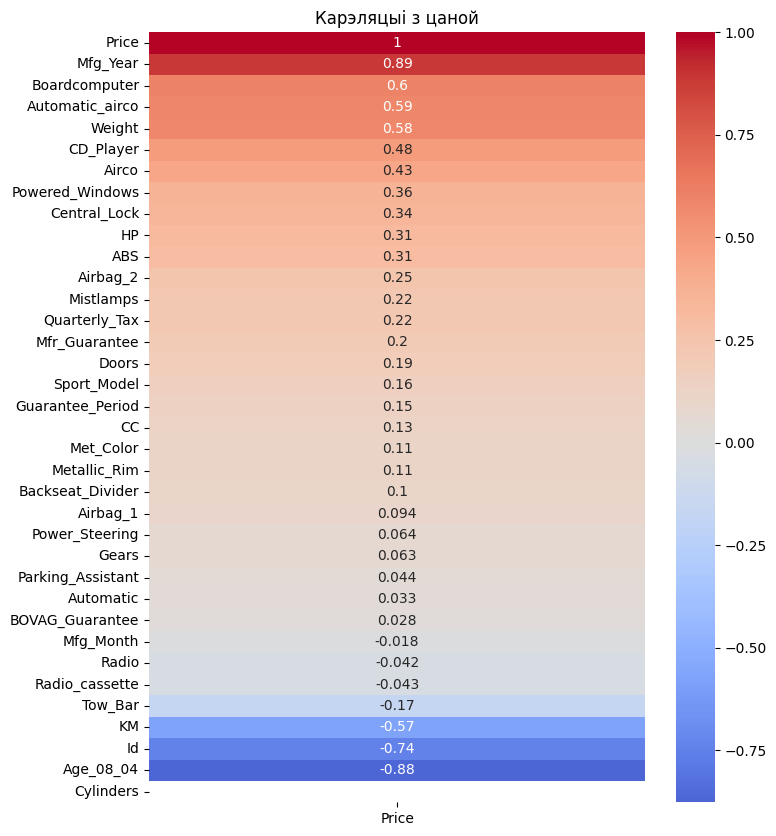

In [33]:
numeric_main = [
    "Price",
    "Age_08_04",
    "KM",
    "HP",
    "CC",
    "Weight",
    "Quarterly_Tax"
]
corr = df[numeric_main].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Матрыца карэляцый")
plt.show()

corr = df.corr(numeric_only=True)

corr_price = corr["Price"].sort_values(ascending=False)

print(corr_price)

plt.figure(figsize=(8,10))

sns.heatmap(
    corr_price.to_frame(),
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Карэляцыі з цаной")
plt.show()

## Вынік EDA

Найбольш на кошт уплываюць наступныя параметры:<br>
- Год выпуску (Mfg_year)
- Наяўнасць бартавога камп'ютара (Boardcomputer)
- Наяўнасць кандыцыянера (Automatic_airco)
- Вага аўтамабіля (Weight)
- Узрост аўтамабіля (Age_08_04)
- Прабег (KM)

*Заўвага. Год выпуску й узрост — узаемазамяняльныя параметры, выкарыстоўваць абодва сэнсу няма.*

<br>Гэтыя параметры будзем выкарыстоўваць для лінейнай рэгрэсіі.

# Feature engineering

### Дублікатныя параметры

Age_08_04, Mfg_Month, Mfg_Year утрымліваюць аднолькавую інфармацыю — узрост машыны. Па сутнасці, тое самае і ў Mfr_Guarantee, Guarantee_Period: гарантыя распаўсюджваецца на новыя машыны. 

### Менш важныя параметры

Cylinders: колькасць цыліндраў рухавіка амаль заўсёды 4, прызнак па сутнасці канстантны.<br>
CC: аб'ём рухавіка няважны, бо мы пакідаем моц (HP).

### Выдаленне

In [34]:
cols_to_drop = [
    "Id",
    "Model",
    "Mfg_Month",
    "Mfg_Year",
    "Cylinders",
    "CC",
    "Mfr_Guarantee",
    "Guarantee_Period"
]

df = df.drop(columns=cols_to_drop)

### Новы параметр — актыўнасць выкарыстання машыны

$$
\text{Usage} = \frac{\text{KM}}{Age\_{08\_04}}
$$

In [35]:
df["Usage"] = df["KM"] / df["Age_08_04"].replace(0,1)

### Кадаванне для Color i Fuel_type

In [36]:
df = pd.get_dummies(df, columns=["Fuel_Type", "Color"], drop_first=True)

# Раздзяленне выбаркі

Выбарку неабходна раздзяляць, каб:
1) мець аб'ектыўную ацэнку якасці мадэлі. Немагчыма праверыць эфектыўнасць мадэлі на тых жа дадзеных, на якіх яна трэніравалася.
2) выяўляць ператрэніроўку й ацэньваць, як мадэль працуе на новых дадзеных.

80% адвядзем на трэніровачную выбарку, 20% на тэставую.

In [37]:
X = df.drop(columns=["Price"])
y = df["Price"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Маштабаванне

In [38]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Трэніроўка мадэляў

In [39]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("LinearRegression:")
print(f"MAE: {mae_lr:.2f}, MSE: {mse_lr:.2f}, R²: {r2_lr:.3f}\n")

LinearRegression:
MAE: 862.22, MSE: 1583819.29, R²: 0.881



In [40]:
ridge = Ridge()
params_ridge = {'alpha': [0.01, 0.1, 1, 10, 100]}

grid_ridge = GridSearchCV(ridge, params_ridge, cv=5, scoring='r2')
grid_ridge.fit(X_train_scaled, y_train)

best_ridge = grid_ridge.best_estimator_
y_pred_ridge = best_ridge.predict(X_test_scaled)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression:")
print(f"Best alpha: {grid_ridge.best_params_['alpha']}")
print(f"MAE: {mae_ridge:.2f}, MSE: {mse_ridge:.2f}, R²: {r2_ridge:.3f}\n")

Ridge Regression:
Best alpha: 10
MAE: 854.66, MSE: 1551549.24, R²: 0.884



In [41]:
lasso = Lasso(max_iter=10000)
params_lasso = {'alpha': [0.01, 0.1, 1, 10, 100]}

grid_lasso = GridSearchCV(lasso, params_lasso, cv=5, scoring='r2')
grid_lasso.fit(X_train_scaled, y_train)

best_lasso = grid_lasso.best_estimator_
y_pred_lasso = best_lasso.predict(X_test_scaled)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso Regression:")
print(f"Best alpha: {grid_lasso.best_params_['alpha']}")
print(f"MAE: {mae_lasso:.2f}, MSE: {mse_lasso:.2f}, R²: {r2_lasso:.3f}\n")

Lasso Regression:
Best alpha: 10
MAE: 855.32, MSE: 1553290.65, R²: 0.884



### Доказ адсутнасці ператрэніроўкі

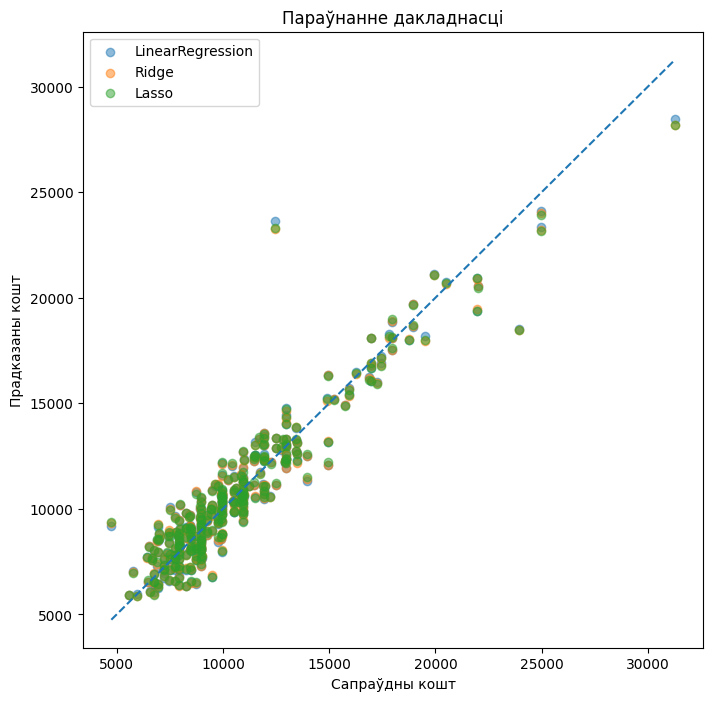

In [42]:
plt.figure(figsize=(8,8))

# Linear Regression
plt.scatter(y_test, y_pred_lr, alpha=0.5, label="LinearRegression")

# Ridge
plt.scatter(y_test, y_pred_ridge, alpha=0.5, label="Ridge")

# Lasso
plt.scatter(y_test, y_pred_lasso, alpha=0.5, label="Lasso")

# Лінія ідэальнага супадзення
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--")

plt.xlabel("Сапраўдны кошт")
plt.ylabel("Прадказаны кошт")
plt.title("Параўнанне дакладнасці")
plt.legend()

plt.show()

### MAPE

In [43]:
mape = np.mean(np.abs((y_test - y_pred_ridge) / y_test)) * 100
print(f"MAPE: {mape:.2f}%")

MAPE: 8.65%


# Вынікі

Паспяхова натрэніраваная мадэль прадказання кошту; вынік адрозніваецца ад рэальнага ў сярэднім на 8,65% ад кошту машыны.